# 02 · The oracle, part 1 — objective metrics

**Execution status:** 🟢 EXECUTED (CPU, outputs saved)
**Plan reference:** PLAN §III.3–§III.4 · THEORY §T7 · PREREG §9

The first of the two independent signals every claim must move. We render four hand-authored fixtures — a clean page, an *AI-slop* page, a broken-layout page, a trivial page — through the **exact deterministic pipeline** the real study uses (headless Chromium → rendered DOM + screenshot), walk each metric family on them, and collapse the vector into the **Primary Objective Composite (POC)**. The payoff is the *slop-vs-clean separation*: proof the oracle can tell good design from bad without a human in the loop.

| | |
|---|---|
| **Inputs** | `fixtures/*.html` (4 hand-authored pages), `config/render.yaml` |
| **Outputs** | metric table, PSI separation, POC + its frozen conditionals, F4 & F10 previews |
| **Runtime** | ~15 s (renders 4 pages headless) |

*Project 19 — Anatomy of a Design Skill. Governance: `CLAUDE.md`. Plan: `PLAN.md`. Derivations:
`THEORY.md`. Freeze: `PREREGISTRATION.md`. This notebook imports tested machinery from the `p19`
package and carries the narrative; it never re-implements logic that lives in `src/p19/`.*

In [1]:
%matplotlib inline
# Bootstrap: locate the repo root (repo-relative — no hardcoded paths) and make p19 importable.
import sys, pathlib
_here = pathlib.Path.cwd()
_root = next((c for c in [_here, *_here.parents]
              if (c / "pyproject.toml").exists() and (c / "src" / "p19").exists()), _here)
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from p19 import REPO_ROOT
np.random.seed(0)                      # notebook-level seed; every generator also takes an explicit seed
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 120)
print("p19 ready · repo:", REPO_ROOT.name)

p19 ready · repo: steering-llm-aesthetics


## §III.3 · Rendering — the metrics see pixels, never code

The single most important rule of the objective oracle (CLAUDE.md): metrics are computed on the
**rendered DOM and screenshot**, never on raw HTML strings. A page that *looks* fine but renders
broken must score broken. Rendering is fully deterministic — fixed viewport 1440×900, device-scale 1,
animations disabled, network **blocked** (any external fetch is aborted and counted as a hermeticity
violation), fonts awaited. `p19.rendering.render_file` returns the DOM tree, an axe-core accessibility
scan, and a screenshot.

In [2]:
# Render all four fixtures headlessly (hermetic, with axe-core) and summarize (p19.rendering).
# Playwright's sync API must run off the kernel's asyncio loop, so we render in worker threads
# (a standard Jupyter + Playwright pattern; on Colab/CLI the direct call is fine).
import tempfile, concurrent.futures
from p19.rendering import render_file
FIXTURES = ["clean_landing", "slop_landing", "overflow_broken", "minimal_valid"]
out = tempfile.mkdtemp()
def _render(name):
    return render_file(REPO_ROOT/"fixtures"/f"{name}.html", out_dir=out, run_axe=True)
with concurrent.futures.ThreadPoolExecutor(max_workers=4) as ex:
    rr = dict(zip(FIXTURES, ex.map(_render, FIXTURES)))
pd.DataFrame([rr[n].summary() for n in FIXTURES], index=FIXTURES)

,gen_id,render_success,hermetic,n_external_requests,console_errors,n_elements
clean_landing,clean_landing,1,1,0,0,40
slop_landing,slop_landing,1,1,0,0,20
overflow_broken,overflow_broken,1,1,0,0,18
minimal_valid,minimal_valid,1,1,0,0,5


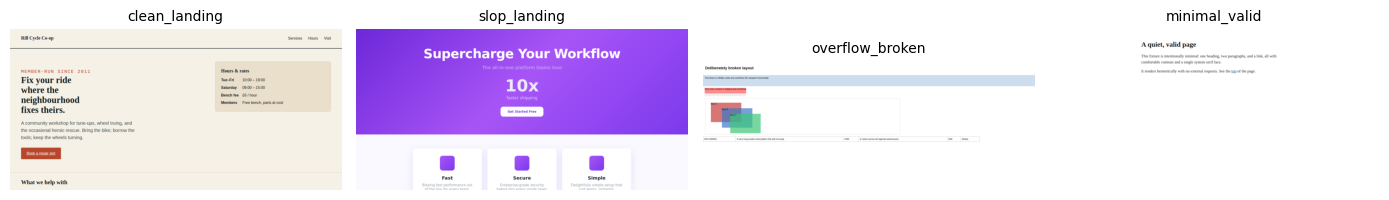

In [3]:
# Display the four rendered screenshots inline (top of each full-page capture).
from PIL import Image
fig, ax = plt.subplots(1, 4, figsize=(14, 4.2))
for a, name in zip(ax, FIXTURES):
    img = Image.open(rr[name].screenshots["desktop"])
    img = img.crop((0, 0, img.width, min(img.height, 700)))   # top 700px for a fair comparison
    a.imshow(img); a.set_title(name, fontsize=10); a.axis("off")
fig.tight_layout(); plt.show()

Eyeball them: **slop_landing** is the caricature the skill's C5 negatives target — a purple gradient,
a centered hero with one big number, three identical icon cards. **clean_landing** is restrained and
deliberate. **overflow_broken** spills content past the viewport. **minimal_valid** is a bare valid
page. The metrics below must agree with your eyes.

## §III.3 · The six metric families

The oracle reports a **vector**, not a single number (aggregating raw metrics hides failures). Six
families, each with a THEORY §T7 formula:

| family | measures | example metric |
|---|---|---|
| **V** validity | does it render, hermetically, without overflow/overlap? | `n_overflow`, axe violations |
| **A** accessibility | WCAG contrast of every text node (T7.1–T7.2) | `contrast_frac_below_4_5` |
| **L** layout | Ngo balance/equilibrium/symmetry, alignment regularity (T7.3) | `ngo_balance`, `align_regularity` |
| **T** typography | distinct sizes/families, modular-scale fit (T7.7) | `type_scale_adherence` |
| **C** color | Hasler colorfulness, dominant colors, the purple-slop index (T7.4, T7.6) | `psi`, `colorfulness` |
| **X** complexity | quadtree visual complexity (T7.5) | `visual_complexity` |

In [4]:
# The full objective metric vector for each fixture (poc.assemble_row merges DOM + screenshot metrics).
from p19 import poc
rows = []
for name in FIXTURES:
    row = poc.assemble_row(rr[name], rr[name].screenshots["desktop"])
    row["render_success"] = int(rr[name].render_success); row["fixture"] = name
    rows.append(row)
M = pd.DataFrame(rows).set_index("fixture")
fam_cols = ["render_success","n_overflow","n_overlap","axe_total",           # V
            "contrast_frac_below_4_5","contrast_min",                          # A
            "ngo_balance","align_regularity","whitespace_ratio",               # L
            "n_font_sizes","type_scale_adherence",                             # T
            "colorfulness","psi","psi_hue","n_dominant_colors",                # C
            "visual_complexity"]                                               # X
M[fam_cols].round(3)

,render_success,n_overflow,n_overlap,axe_total,contrast_frac_below_4_5,contrast_min,ngo_balance,align_regularity,whitespace_ratio,n_font_sizes,type_scale_adherence,colorfulness,psi,psi_hue,n_dominant_colors,visual_complexity
fixture,,,,,,,,,,,,,,,,
clean_landing,1,0,0,2,0.000,4.725,0.628,-0.675,0.207,4,0.667,16.478,0.000,0.000,2,0.206
slop_landing,1,0,0,6,0.667,1.047,0.952,-1.500,0.285,8,0.714,96.291,0.849,0.996,4,0.116
overflow_broken,1,9,8,0,0.167,3.747,0.263,-1.111,0.654,2,0.000,21.567,0.002,0.007,1,0.060
minimal_valid,1,0,0,0,0.000,8.393,0.000,-2.200,0.919,3,0.500,2.618,0.001,0.005,1,0.000


Read down the columns. **overflow_broken** is the only page with `n_overflow` > 0 (9 elements spill) —
family V catches it. **slop_landing** has `contrast_frac_below_4_5` = 0.67 (two-thirds of its text
fails WCAG AA), `colorfulness` ≈ 96 (garish), and `psi_hue` ≈ 1.0 (its salient pixels are almost
entirely purple). **clean_landing** passes contrast, sits at moderate colorfulness, and has `psi` = 0.
Each family fires exactly where a designer's eye would.

### Family A up close — WCAG contrast (THEORY §T7.1–T7.2)

Contrast ratio is `CR = (L₁ + 0.05)/(L₂ + 0.05)` on linearized-sRGB luminances, ranging 1→21. The
size-aware AA bar is 4.5 (3.0 for large text). This is the archetypal deterministic accessibility
endpoint — no model, no judge.

In [5]:
# WCAG contrast ratio on reference pairs (THEORY T7.2) + the per-fixture failing fraction.
from p19.metrics_dom import contrast_ratio
print("black on white :", round(contrast_ratio([0,0,0],[255,255,255]), 2), "(max, 21:1)")
print("#888 on white  :", round(contrast_ratio([136,136,136],[255,255,255]), 2), "(fails AA body)")
print("white on #7c3aed:", round(contrast_ratio([255,255,255],[124,58,237]), 2), "(the slop purple)")
M[["contrast_frac_below_4_5","contrast_min","contrast_median"]].round(3)

black on white : 21.0 (max, 21:1)
#888 on white  : 3.54 (fails AA body)
white on #7c3aed: 5.7 (the slop purple)


,contrast_frac_below_4_5,contrast_min,contrast_median
fixture,,,
clean_landing,0.000,4.725,12.663
slop_landing,0.667,1.047,2.539
overflow_broken,0.167,3.747,18.883
minimal_valid,0.000,8.393,14.159


## §III.3.1 · The purple-slop index (PSI) — the skill's own negatives, made measurable

The skill's C5 component tells the model exactly what *not* to do: purple/indigo gradients, Inter/
Roboto, centered hero-with-a-big-number. So we measure those very tells. `PSI = 0.30·hueFrac[260–290°]
+ 0.30·gradientBg + 0.25·InterRobotoShare + 0.15·centeredHero` (THEORY §T7.6), each subcomponent in
[0,1], **lower = less slop**.

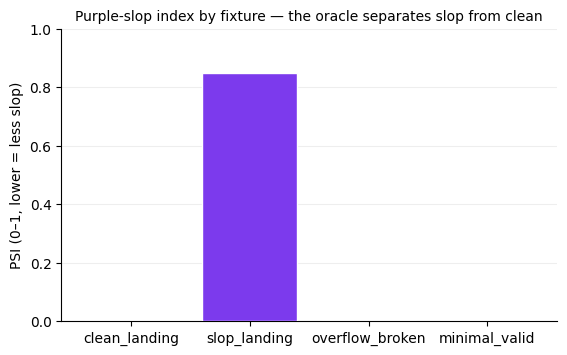

,psi,psi_hue,psi_gradient,psi_inter,psi_centered
fixture,,,,,
clean_landing,0.000,0.000,0.0,0.0,0.0
slop_landing,0.849,0.996,0.5,1.0,1.0
overflow_broken,0.002,0.007,0.0,0.0,0.0
minimal_valid,0.001,0.005,0.0,0.0,0.0


In [6]:
# PSI composite + subcomponents per fixture, and the slop-vs-clean separation (the oracle sanity proof).
psi_cols = ["psi","psi_hue","psi_gradient","psi_inter","psi_centered"]
sep = M[psi_cols].round(3)
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.bar(M.index, M["psi"], color=["#009E73","#7c3aed","#E69F00","#56B4E9"], edgecolor="white", zorder=3)
ax.set_ylabel("PSI (0–1, lower = less slop)"); ax.set_ylim(0, 1)
ax.set_title("Purple-slop index by fixture — the oracle separates slop from clean", fontsize=10)
ax.grid(True, axis="y", color="#eee"); ax.set_axisbelow(True)
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.show()
sep

**This is the oracle's sanity proof.** With *no human and no judge*, PSI ranks the slop page at
**0.85** and the clean page at **0.00** — a full-scale separation driven by the deterministic pixel
and DOM measurements. If the objective half could not tell these two fixtures apart, nothing
downstream would be trustworthy. It can.

## §III.4 · The Primary Objective Composite (POC) — one number, honestly built

For the confirmatory tests we need **one** objective scalar per generation while still respecting
"don't average raw metrics." The POC (THEORY §T7.10) is the mean of **seven oriented, z-scored** core
terms: `+align_regularity, +whitespace, +type_scale, +contrast_pass_rate, −overflow/overlap, −PSI,
−|colorfulness − c*|`. Render-failed pages are **excluded** (a non-rendering page is a validity null,
counted in family V). Two **frozen conditionals** travel with the endpoint (not post-hoc): drop the
−PSI term if PSI fails its gate (a 6-term POC), and a pre-stated fallback for the colorfulness anchor
`c*`.

In [7]:
# POC on the fixtures, showing the frozen conditionals that fire (poc.compute_poc; THEORY T7.10).
res7 = poc.compute_poc(M, psi_admit=True)
M["poc"] = res7["poc"].values
print("7-term POC: c* =", round(res7["c_star"],2), "| c* branch =", res7["c_star_branch"],
      "| n_terms =", res7["n_terms"])
# demonstrate conditional (i): if PSI failed its admission gate, the confirmatory POC drops -PSI
res6 = poc.compute_poc(M, psi_admit=False)
comp = pd.DataFrame({"POC (7-term)": res7["poc"], "POC (6-term, PSI-out)": res6["poc"]}, index=M.index)
comp.round(3).sort_values("POC (7-term)", ascending=False)

7-term POC: c* = 19.02 | c* branch = population | n_terms = 7


,POC (7-term),"POC (6-term, PSI-out)"
fixture,,
clean_landing,0.500,0.486
minimal_valid,0.316,0.273
overflow_broken,-0.144,-0.263
slop_landing,-0.672,-0.496


The POC orders the fixtures exactly as a designer would — **clean (+0.50) > minimal (+0.32) > broken
(−0.14) > slop (−0.67)** — and the two conditionals are *measurable before any test is run*, so the
estimand is well-defined in advance. On the fixtures `c*` uses the `population` branch (no FULL cell
present); on the real dev set it will use `dev_full` (the skill-on colorfulness distribution) unless
≥30 human-preferred pages are available. Whichever branch fires is recorded in the manifest before the
first confirmatory test.

> ## ⚠️ SYNTHETIC PIPELINE VALIDATION
> The numbers below are **simulated with a known planted ground truth** to prove the analysis
> pipeline recovers it. The two oracle-*validation* figures (F4, F10) need many labeled units, which arrive only after the GPU render phase; here they are planted previews so you can see the plot and the gate logic. **Real data replaces this after the GPU phase (see `RUNBOOK.md`).**
> Every synthetic artifact in this notebook is generated by `p19.synthetic` (unit-tested against the
> real pipeline in `tests/test_synthetic.py`).

## §III.3.1 · F4 — which metrics are redundant?

Before trusting the vector we expose redundancy: a Spearman correlation matrix across metrics, blocked
by family. Redundant metrics cluster; the POC deliberately z-scores a *pre-registered subset*, not all
of them. The preview below plants weak cross-family + strong within-family correlation — the block
structure the real F4 will show on 4,630 renders.

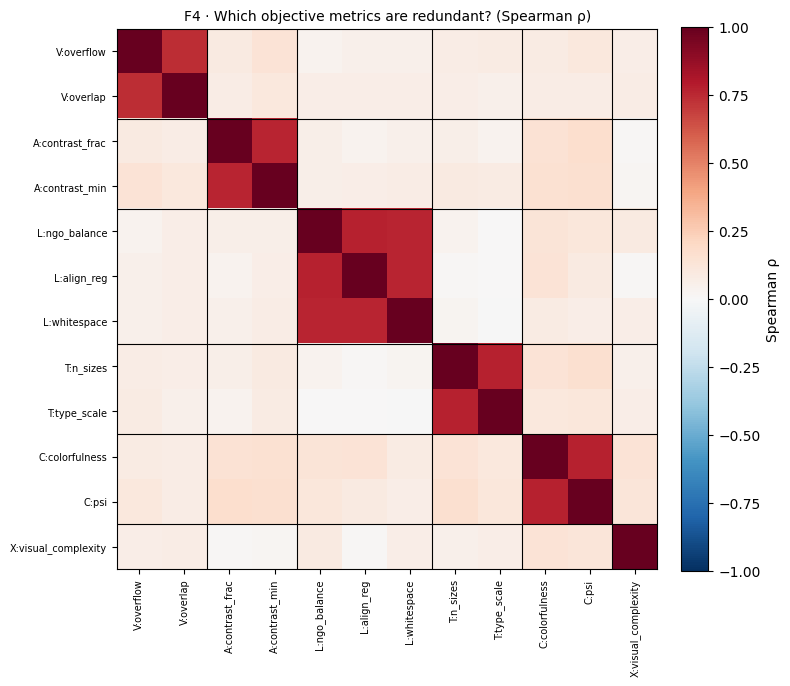

In [8]:
# F4 preview — metric-correlation matrix with planted family blocks (p19.synthetic + p19.figures).
from p19 import synthetic as syn, figures
corr, labels, bounds = syn.metric_correlation_preview(n=600, seed=0)
figures.metric_correlation_matrix(corr, labels, family_bounds=bounds); plt.show()

Bright within-family blocks along the diagonal (redundant metrics), dimmer cross-family cells
(families capture distinct information). The real F4 is the guardrail against a POC that secretly
double-counts one axis.

## §PREREG-9 · F10 — is PSI allowed to be evidence?

PSI is admitted into the confirmatory POC **only if** it tracks human "looks AI-generated" judgment:
Spearman ρ(PSI, human rating) ≥ 0.40 on the human subset. If it fails, PSI is demoted to a diagnostic
and the confirmatory POC becomes the 6-term variant (the conditional demonstrated above). The preview
plants ρ ≈ 0.55 — a passing judge-of-the-judge.

realized Spearman ρ = 0.67  →  ADMIT PSI (7-term POC)


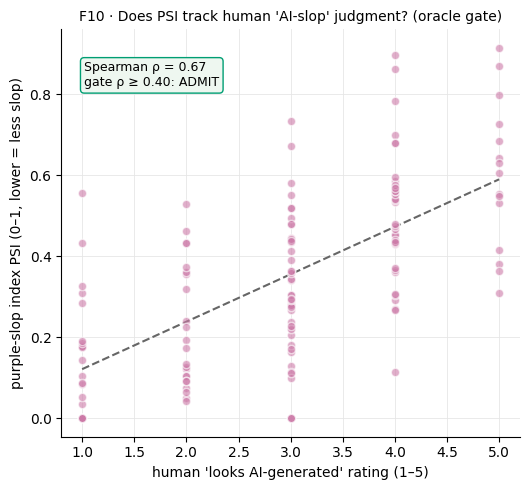

In [9]:
# F10 preview — PSI vs human "AI-generated" rating, with the ρ≥0.40 admission gate (PREREG §9).
human, psi, rho = syn.psi_validation_preview(n=140, rho=0.55, seed=0)
print(f"realized Spearman ρ = {rho:.2f}  →  {'ADMIT PSI (7-term POC)' if rho>=0.40 else 'DEMOTE (6-term POC)'}")
figures.psi_validation(human, psi, rho); plt.show()

ρ ≈ 0.55 clears the 0.40 gate, so PSI stays in the 7-term POC. Had it failed, the frozen conditional
would have swapped in the 6-term POC for every confirmatory decision — no re-litigation, because the
rule was fixed in advance.

---
**Next:** notebook **03** builds the second oracle signal — the pairwise preference protocol, its
reliability gate, and its power analysis.